In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deep_belief_betting.parameters import Parameters
from deep_belief_betting.market_sim import MarketSim
from deep_belief_betting.pretraining_path_generator import PretrainingPathGenerator
from deep_belief_betting.prediction_market_env import PredictionMarketEnv
from deep_belief_betting.smoke_train import SmokeTrainConfig, run_smoke_training

In [14]:
params = Parameters.from_yaml(PROJECT_ROOT / "configs" / "default.yaml")

print("seed", params.seed)
print("num_steps", params.num_steps)
print("b", params.lmsr.b)
print("trade_size", params.trade_size())
print("reward_mode", params.reward.reward_mode)
print("belief_mode", params.belief_features.mode)

seed 20260424
num_steps 60
b 20.0
trade_size 2
reward_mode terminal_net_pnl
belief_mode none


In [15]:
sim = MarketSim(params)
state = sim.reset(seed=123)

rows = []
rows.append(
    {
        "step": state.step,
        "time_to_resolution": state.time_to_resolution,
        "x": state.x,
        "q": state.q,
        "public_probability": state.public_probability,
        "latent_probability": state.latent_probability,
        "delta_q": state.delta_q,
        "informed_flow": state.informed_flow,
        "noise_flow": state.noise_flow,
        "terminal_outcome": state.terminal_outcome,
    }
)

done = False
while not done:
    state, done = sim.step()
    rows.append(
        {
            "step": state.step,
            "time_to_resolution": state.time_to_resolution,
            "x": state.x,
            "q": state.q,
            "public_probability": state.public_probability,
            "latent_probability": state.latent_probability,
            "delta_q": state.delta_q,
            "informed_flow": state.informed_flow,
            "noise_flow": state.noise_flow,
            "terminal_outcome": state.terminal_outcome,
        }
    )

len(rows), rows[0], rows[-1]

(61,
 {'step': 0,
  'time_to_resolution': 60,
  'x': 0.0,
  'q': 0.0,
  'public_probability': np.float64(0.5),
  'latent_probability': np.float64(0.5),
  'delta_q': 0.0,
  'informed_flow': 0.0,
  'noise_flow': 0.0,
  'terminal_outcome': 1},
 {'step': 60,
  'time_to_resolution': 0,
  'x': np.float64(0.5637676230630617),
  'q': 2.0,
  'public_probability': np.float64(0.52497918747894),
  'latent_probability': np.float64(0.6373238465884808),
  'delta_q': 0.0,
  'informed_flow': 0.0,
  'noise_flow': 0.0,
  'terminal_outcome': 1})

In [16]:
df = pd.DataFrame(rows)
df

,step,time_to_resolution,x,q,public_probability,latent_probability,delta_q,informed_flow,noise_flow,terminal_outcome
0,0,60,0.000000,0.0,0.500000,0.500000,0.0,0.0,0.0,1
1,1,59,0.144711,-3.0,0.462570,0.536115,-3.0,-3.0,0.0,1
2,2,58,0.047671,-2.0,0.475021,0.511916,1.0,0.0,1.0,1
3,3,57,0.111536,-2.0,0.475021,0.527855,0.0,0.0,0.0,1
4,4,56,0.253509,0.0,0.500000,0.563040,2.0,3.0,-1.0,1
...,...,...,...,...,...,...,...,...,...,...
56,56,4,0.276264,-7.0,0.413382,0.568630,-4.0,-3.0,-1.0,1
57,57,3,0.264466,-2.0,0.475021,0.565734,5.0,4.0,1.0,1
58,58,2,0.395090,1.0,0.512497,0.597507,3.0,3.0,0.0,1
59,59,1,0.368830,2.0,0.524979,0.591176,1.0,0.0,1.0,1


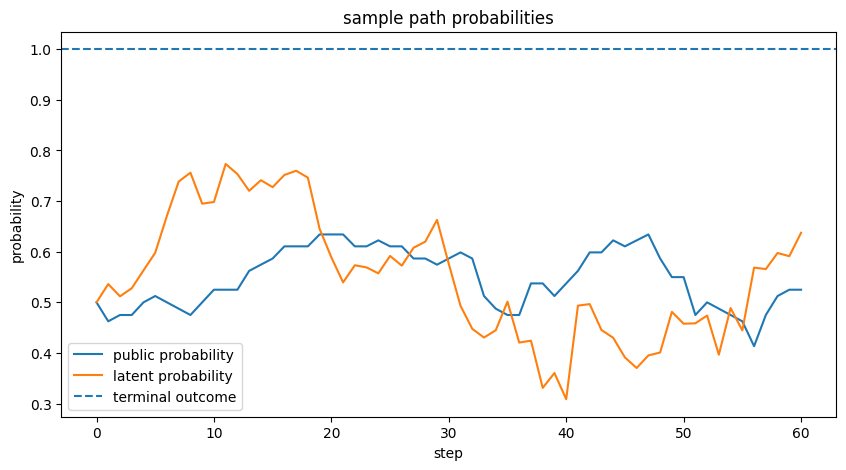

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df["step"], df["public_probability"], label="public probability")
plt.plot(df["step"], df["latent_probability"], label="latent probability")
plt.axhline(df["terminal_outcome"].iloc[0], linestyle="--", label="terminal outcome")
plt.xlabel("step")
plt.ylabel("probability")
plt.title("sample path probabilities with little noise and b value of 20")
plt.legend()
plt.show()

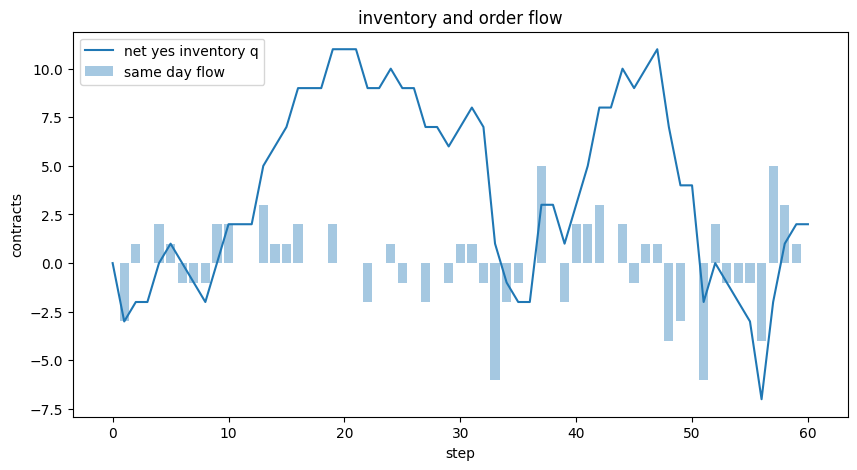

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df["step"], df["q"], label="net yes inventory q")
plt.bar(df["step"], df["delta_q"], alpha=0.4, label="same day flow")
plt.xlabel("step")
plt.ylabel("contracts")
plt.title("inventory and order flow")
plt.legend()
plt.show()

In [19]:
generator = PretrainingPathGenerator(params)
episode = generator.generate_episode(seed=321)

print("features shape", episode["features"].shape)
print("terminal label", episode["terminal_label"])
print("next public probability shape", episode["next_public_probability"].shape)
print("next flow sign shape", episode["next_flow_sign"].shape)

episode["features"][:5]

features shape (60, 3)
terminal label [1.]
next public probability shape (60,)
next flow sign shape (60,)


array([[ 0.5       ,  0.        , 60.        ],
       [ 0.53742987,  3.        , 59.        ],
       [ 0.53742987,  0.        , 58.        ],
       [ 0.5       , -3.        , 57.        ],
       [ 0.5       ,  0.        , 56.        ]], dtype=float32)

In [20]:
env = PredictionMarketEnv(params=params, belief_dim=0)

obs, info = env.reset(seed=42)
print("obs shape", obs.shape)
print("initial obs", obs)
print("initial mask", info["action_mask"])

for t in range(5):
    action_mask = info["action_mask"]
    valid_actions = np.where(action_mask == 1)[0]
    action = int(np.random.choice(valid_actions))

    obs, reward, terminated, truncated, info = env.step(action)

    print(
        {
            "t": t,
            "action": action,
            "reward": reward,
            "terminated": terminated,
            "truncated": truncated,
            "mask": info["action_mask"],
            "realised_cash_pnl": info["realised_cash_pnl"],
            "net_pnl_if_liquidated_now": info["net_pnl_if_liquidated_now"],
        }
    )

    if terminated or truncated:
        break

obs shape (11,)
initial obs [ 0.5        0.        60.         0.         0.         0.
  0.         1.075502  -0.9245229  0.         0.       ]
initial mask [1 1 1 0]
{'t': 0, 'action': 2, 'reward': 0.0, 'terminated': False, 'truncated': False, 'mask': array([1, 0, 0, 1], dtype=int8), 'realised_cash_pnl': 0.9245229045226248, 'net_pnl_if_liquidated_now': -0.07600412595469563}
{'t': 1, 'action': 0, 'reward': 0.0, 'terminated': False, 'truncated': False, 'mask': array([1, 0, 0, 1], dtype=int8), 'realised_cash_pnl': 0.9245229045226248, 'net_pnl_if_liquidated_now': -0.07600412595469563}
{'t': 2, 'action': 3, 'reward': 0.0, 'terminated': False, 'truncated': False, 'mask': array([1, 0, 0, 0], dtype=int8), 'realised_cash_pnl': -0.07600412595469563, 'net_pnl_if_liquidated_now': -0.07600412595469563}
{'t': 3, 'action': 0, 'reward': 0.0, 'terminated': False, 'truncated': False, 'mask': array([1, 0, 0, 0], dtype=int8), 'realised_cash_pnl': -0.07600412595469563, 'net_pnl_if_liquidated_now': -0.076

In [21]:
smoke_config = SmokeTrainConfig(
    num_envs=4,
    num_updates=5,
    rollout_steps=16,
    learning_rate=1e-3,
    hidden_dim=64,
    gamma=0.99,
    device="cpu",
)

run_smoke_training(params=params, config=smoke_config)

update=000 loss=0.0112 policy_loss=0.0092 value_loss=0.0020 mean_rollout_reward=0.0000
update=001 loss=0.0036 policy_loss=-0.0000 value_loss=0.0036 mean_rollout_reward=0.0000
update=002 loss=0.0053 policy_loss=-0.0000 value_loss=0.0053 mean_rollout_reward=0.0000
update=003 loss=0.0025 policy_loss=-0.0046 value_loss=0.0071 mean_rollout_reward=0.0162
update=004 loss=0.0004 policy_loss=-0.0002 value_loss=0.0006 mean_rollout_reward=0.0000


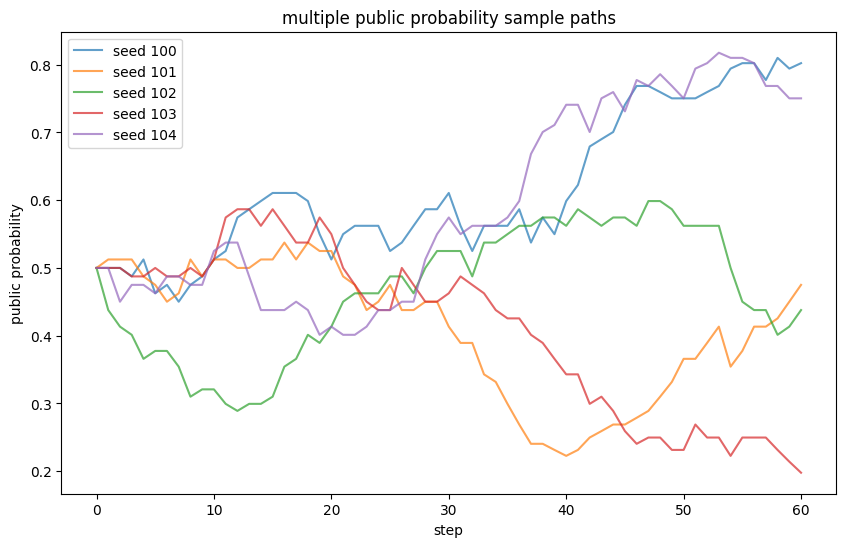

In [22]:
def generate_path_dataframe(params: Parameters, seed: int) -> pd.DataFrame:
    sim = MarketSim(params)
    state = sim.reset(seed=seed)

    rows = []
    rows.append(
        {
            "seed": seed,
            "step": state.step,
            "public_probability": state.public_probability,
            "latent_probability": state.latent_probability,
            "q": state.q,
            "delta_q": state.delta_q,
            "terminal_outcome": state.terminal_outcome,
        }
    )

    done = False
    while not done:
        state, done = sim.step()
        rows.append(
            {
                "seed": seed,
                "step": state.step,
                "public_probability": state.public_probability,
                "latent_probability": state.latent_probability,
                "q": state.q,
                "delta_q": state.delta_q,
                "terminal_outcome": state.terminal_outcome,
            }
        )

    return pd.DataFrame(rows)


dfs = [generate_path_dataframe(params, seed=100 + i) for i in range(5)]
multi_df = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(10, 6))
for seed, sub_df in multi_df.groupby("seed"):
    plt.plot(sub_df["step"], sub_df["public_probability"], alpha=0.7, label=f"seed {seed}")
plt.xlabel("step")
plt.ylabel("public probability")
plt.title("multiple public probability sample paths")
plt.legend()
plt.show()